## Phase 2: Model Training and Evaluation

In this phase, the preprocessed dataset from Phase 1 is used to train and evaluate machine learning models for support ticket classification. The main objectives are:

- creating train, validation, and test splits,
- addressing the observed class imbalance,
- selecting and training an appropriate classification model,
- evaluating model performance using suitable metrics,
- optimizing model performance through hyperparameter tuning.

#### Create a train, test and validation split
We load the in phase 1 created .csv file with the preprocessed/cleaned data. And create a train, test and vaildation split using stratified sampling. The test set is kept completely unseen during model training and hyperparameter tuning and is only used for final evaluation. As stated in phase 1, we will try to predict the department as well as the priority of a given ticket. First, we will focus on just predicting the department alone and later on we will tackle multiple outputs.

In [1]:
import pandas as pd
import sklearn
from sklearn.model_selection import train_test_split

filepath = "../data/dataset_en_clean.csv"
df = pd.read_csv(filepath) # Load the in phase 1 prepared data

X = df["clean_text"] 
y = df["queue"]

# Create train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=15, stratify=y) 

# Create train-validation split
X_train, X_validation, y_train, y_validation = train_test_split(X_train, y_train, test_size=0.20, random_state=15, stratify=y_train)

#### Verctorize the data
TF-IDF is used to transform the cleaned text data into numerical feature vectors suitable for machine learning models.

In [2]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)

# Apply vectorization
X_train_vec = vectorizer.fit_transform(X_train) 
X_test_vec = vectorizer.transform(X_test)
X_validation_vec = vectorizer.transform(X_validation)

#### Handle the class imbalance
When looking at the number at data points per label (department), we still see the in phase 1 observed imbalance in terms of class distribution. 

In [3]:
print(y_train.value_counts())

queue
technical support                  3221
product support                    2089
customer service                   1638
it support                         1321
billing and payments               1085
returns and exchanges               557
service outages and maintenance     451
sales and pre-sales                 349
human resources                     237
general inquiry                     161
Name: count, dtype: int64


To handle this imbalance, we will apply oversampling, where random samples are used multiple times to balance the number of samples (Using differnt class weights was also tried and perfomed a little bit worse than oversampling in this scenario). When looking at the resulting distribution of classes, we see that they are now balanced in terms of occurance. We have seen in phase 1, that the median word count per message is balanced already and requires no further action as well 

In [4]:
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=0)

# Resample the training data to balance it
X_resampled, y_resampled = ros.fit_resample(X_train_vec, y_train)

print(y_resampled.value_counts())

queue
product support                    3221
customer service                   3221
billing and payments               3221
it support                         3221
technical support                  3221
service outages and maintenance    3221
returns and exchanges              3221
sales and pre-sales                3221
human resources                    3221
general inquiry                    3221
Name: count, dtype: int64


#### Choose and train a model

To detrmine what machine learning algorithm fits our task, I like to use the cheat sheet below. We know that we have a supervised classification problem at hand, so our first choice has to be whether we are going for accuracy or speed. Since we want a reliable system and the training data set is relatively small, we will focus on accuracy. Finally we need to choose an algorithm. Random Forest was selected due to its robustness, ability to handle high-dimensional feature spaces, and its strong baseline performance on text classification tasks ('Gradient Boosting' was also tested but performed noticeably worse).

![Machine Learning Algorithm Cheat Sheet](../assets/ml_cheat_sheet.png)

In [5]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

model = RandomForestClassifier(verbose=1, random_state=42, n_jobs=-1) # Initialize the model 
model.fit(X_resampled, y_resampled) # Train the model

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    2.3s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    8.0s finished


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

#### Evaluate and tune the model
For the evaluation we will first take a look at a confusion matrix (in this case just for the test data results). Initially the perfomance looks rather weak when it comes to the 'True Positives' but one may notice that the sum of 'False Positives' and 'False Negatives' each are rather compared to low to the number of 'True Positives'. The reason for this is that the distibution classes in the test data is still uneven, highlighting classes with more samples more.

[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 100 out of 100 | elapsed:    0.0s finished


<Axes: >

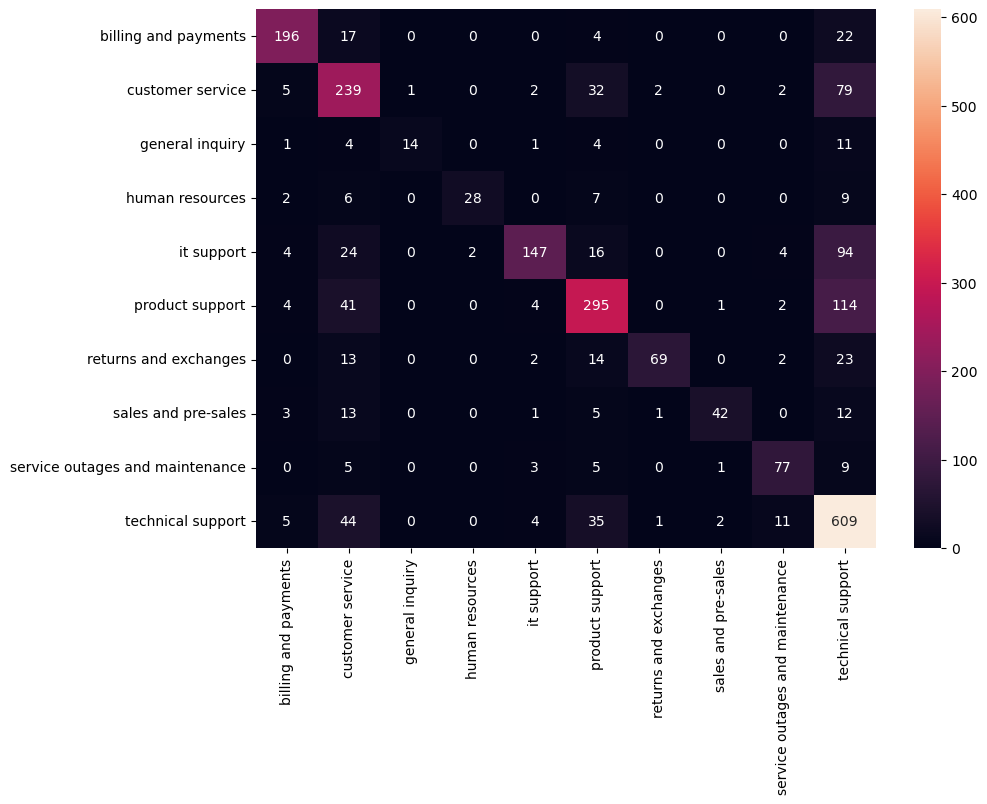

In [6]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = model.predict(X_test_vec)
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)

plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt='g', xticklabels=model.classes_, yticklabels=model.classes_,)

When inspecting the precison, recall and f1-score as well as support for each class (for either test and validation, since they are close to eah other), we see the mentioned imbalance in class distribution in the test data (Said inbalance will be kept, since in a real world scenario, the distribution would be uneven as well). Were the class 'technical support' perfomed the best on the confusion matrix for example, we now observe a relatively low precision and average f1-score.

For this scenario, we want to have a high f1-score so that tickets are not constantly routed to the wrong department. The overall f1-score is already decent but for several singular classes (e.g. 'general inquiry') its still rather low, meaning the model will perform espacially poor in these cases. As such, in the next step we will perfom some model tuning, to improve the models perfomance.

In [7]:
print("Test Results:")
print(classification_report(y_test, y_pred))

y_val_pred = model.predict(X_validation_vec)
print("Validation Results:")
print(classification_report(y_validation, y_val_pred))

Test Results:
                                 precision    recall  f1-score   support

           billing and payments       0.89      0.82      0.85       239
               customer service       0.59      0.66      0.62       362
                general inquiry       0.93      0.40      0.56        35
                human resources       0.93      0.54      0.68        52
                     it support       0.90      0.51      0.65       291
                product support       0.71      0.64      0.67       461
          returns and exchanges       0.95      0.56      0.70       123
            sales and pre-sales       0.91      0.55      0.68        77
service outages and maintenance       0.79      0.77      0.78       100
              technical support       0.62      0.86      0.72       711

                       accuracy                           0.70      2451
                      macro avg       0.82      0.63      0.69      2451
                   weighted avg    

[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 100 out of 100 | elapsed:    0.0s finished


#### Tune the model

To try and improve the models performance, we will use GridSearchCV. With this, we can do an "exhaustive search over specified parameter values for an estimator"[^1]. We train the resulting model again.

[^1]: [GridSearchCV Documentation](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html)

In [8]:
from sklearn.model_selection import GridSearchCV

# Define parameter grid
parameters = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'max_features': ['sqrt', 'log2'],
}

tree = RandomForestClassifier(verbose= 0, random_state=42, n_jobs=-1) # Initialize a model
model = GridSearchCV(tree,parameters) # Use grid serach, to find the best performing model with the given parameters
model.fit(X_resampled, y_resampled) # Train the model

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [10, 20, ...], 'max_features': ['sqrt', 'log2'], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed

The new model shows some minor improvements but overall performs rather similar to the original model (other resampling methods, paramters and estimators were tested and the results are similar).  While there is more that can be done with machine learning methods, we will instead explore the capabilities of deep learning methods next.

In [9]:
y_pred = model.predict(X_test_vec)
print("Test Results:")
print(classification_report(y_test, y_pred))

y_val_pred = model.predict(X_validation_vec)
print("Validation Results:")
print(classification_report(y_validation, y_val_pred))

Test Results:
                                 precision    recall  f1-score   support

           billing and payments       0.93      0.83      0.88       239
               customer service       0.63      0.71      0.66       362
                general inquiry       1.00      0.40      0.57        35
                human resources       0.93      0.50      0.65        52
                     it support       0.90      0.53      0.67       291
                product support       0.76      0.68      0.72       461
          returns and exchanges       0.96      0.59      0.73       123
            sales and pre-sales       0.96      0.61      0.75        77
service outages and maintenance       0.92      0.73      0.82       100
              technical support       0.64      0.89      0.74       711

                       accuracy                           0.73      2451
                      macro avg       0.86      0.65      0.72      2451
                   weighted avg    